In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using {device} device")
if device==torch.device("cuda"):print(torch.cuda.get_device_name(0))  # Nom du GPU


features=np.array(["5_o_Clock_Shadow","Arched_Eyebrows","Attractive",
          "Bags_Under_Eyes","Bald","Bangs","Big_Lips","Big_Nose",
          "Black_Hair","Blond_Hair","Blurry","Brown_Hair","Bushy_Eyebrows",
          "Chubby","Double_Chin","Eyeglasses","Goatee","Gray_Hair","Heavy_Makeup",
          "High_Cheekbones","Male","Mouth_Slightly_Open","Mustache","Narrow_Eyes",
          "No_Beard","Oval_Face","Pale_Skin","Pointy_Nose","Receding_Hairline","Rosy_Cheeks",
          "Sideburns","Smiling","Straight_Hair","Wavy_Hair","Wearing_Earrings","Wearing_Hat","Wearing_Lipstick",
          "Wearing_Necklace","Wearing_Necktie","Young"])

Using cuda device
NVIDIA GeForce RTX 3060 Ti


In [2]:
import os

celeba_path = '../celeba/img_align_celeba'
print(os.getcwd())
files = os.listdir(celeba_path)
print(f"Nombre de fichiers : {len(files)}")
print("Exemples de fichiers :", files[:10])

C:\Users\ramigon\Downloads\8INF883\CVAE
Nombre de fichiers : 202599
Exemples de fichiers : ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg', '000007.jpg', '000008.jpg', '000009.jpg', '000010.jpg']


In [3]:
import os
import torch
import pandas as pd
from torch.utils.data import Dataset
from torchvision.transforms import Resize
from torchvision.io import read_image
import torchvision.transforms as T

celeba_root = "../celeba"
img_dir = os.path.join(celeba_root, "img_align_celeba")
attr_path = os.path.join(celeba_root, "list_attr_celeba.csv")
partition_path = os.path.join(celeba_root, "list_eval_partition.csv")

attr_df = pd.read_csv(
    attr_path,
    skiprows=1,
    names=['filename'] + features.tolist(),
    index_col='filename'
)
#print(attr_df)

partition_df = pd.read_csv(
    partition_path,
    header=None,
    names=['filename', 'partition'],
    index_col='filename'
)

partition_df.columns = ['partition']
#print(partition_df)

attr_df['partition'] = partition_df['partition']
#print(attr_df)

attr_df = attr_df.replace(-1, 0)

class CelebADataset(Dataset):
    def __init__(self, img_dir, attr_df, transform=None):
        self.img_dir = img_dir
        self.attr_df = attr_df
        self.transform = transform
        self.image_names = attr_df.index.tolist()

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = read_image(img_path).float() / 255.0
        label = torch.tensor(self.attr_df.loc[img_name].values, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

train_df = attr_df[attr_df['partition'] == "0"].drop(columns='partition')
test_df  = attr_df[attr_df['partition'] == "2"].drop(columns='partition')
val_df   = attr_df[attr_df['partition'] == "1"].drop(columns='partition')

test_transform = T.Compose([T.Resize((128,128)) , T.RandomHorizontalFlip(p=0.5)  ])

transform = Resize((128, 128), antialias=True)

training_data = CelebADataset(img_dir, train_df, transform=test_transform)
test_data  = CelebADataset(img_dir, test_df, transform=transform)
val_data   = CelebADataset(img_dir, val_df, transform=transform)

In [4]:
print(training_data.__len__())
print(test_data.__len__())
print(val_data.__len__())

162770
19962
19867


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


['Arched_Eyebrows' 'Attractive' 'Brown_Hair' 'Heavy_Makeup'
 'High_Cheekbones' 'Mouth_Slightly_Open' 'No_Beard' 'Pointy_Nose'
 'Smiling' 'Straight_Hair' 'Wearing_Earrings' 'Wearing_Lipstick' 'Young']


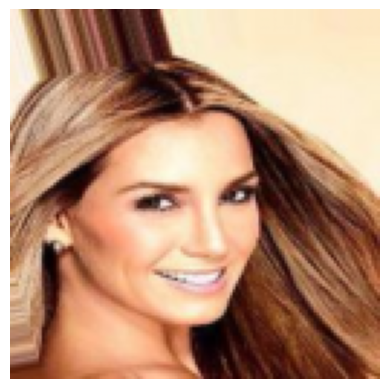

torch.Size([128, 128, 3])


In [5]:
# Tests pour vérifier la bonne implémentation du dataset
img, attr = training_data[0]
img = img.permute(1, 2, 0)

attr = attr.numpy()

plt.imshow(img)
plt.axis('off')
print(features[attr == 1])
plt.show()
print(img.shape)

In [6]:
batch_size = 512

# Création des data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)
val_dataloader = DataLoader(val_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")

    break

Shape of X [N, C, H, W]: torch.Size([512, 3, 128, 128])
Shape of y: torch.Size([512, 40]) torch.float32


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CVAE(nn.Module):
    def __init__(self, latent_dim=512, num_classes=40):
        super(CVAE, self).__init__()
        self.num_classes = num_classes
        
        self.enc_conv1 = nn.Conv2d(3 + num_classes, 64, kernel_size=4, stride=2, padding=1)
        self.enc_bn1 = nn.BatchNorm2d(64)
        self.enc_conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.enc_bn2 = nn.BatchNorm2d(128)
        self.enc_conv3 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.enc_bn3 = nn.BatchNorm2d(256)
        self.enc_conv4 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)
        self.enc_bn4 = nn.BatchNorm2d(512)
        self.enc_conv5 = nn.Conv2d( 512,1024, kernel_size=4, stride=2, padding=1)
        self.enc_bn5 = nn.BatchNorm2d(1024)
        
        self.fc_mu = nn.Linear(1024 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(1024 * 4 * 4, latent_dim)
        
        self.dec_fc = nn.Linear(latent_dim + num_classes,1024 * 4 * 4)
        
        self.dec_conv0 = nn.ConvTranspose2d(1024,512, kernel_size=4, stride=2, padding=1)
        self.dec_bn0 = nn.BatchNorm2d(512)  
        self.dec_conv1 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)
        self.dec_bn1 = nn.BatchNorm2d(256)
        self.dec_conv2 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        self.dec_bn2 = nn.BatchNorm2d(128)
        self.dec_conv3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.dec_bn3 = nn.BatchNorm2d(64)
        self.dec_conv4 = nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1)

    def encode(self, x, c):
        batch_size, _, h, w = x.size()
        c_expanded = c.view(batch_size, self.num_classes, 1, 1).expand(-1, -1, h, w)
        x = torch.cat([x, c_expanded], dim=1)
        
        x = F.leaky_relu(self.enc_bn1(self.enc_conv1(x)), 0.2)
        x = F.leaky_relu(self.enc_bn2(self.enc_conv2(x)), 0.2)
        x = F.leaky_relu(self.enc_bn3(self.enc_conv3(x)), 0.2)
        x = F.leaky_relu(self.enc_bn4(self.enc_conv4(x)), 0.2)
        x = F.leaky_relu(self.enc_bn5(self.enc_conv5(x)), 0.2)
        x = x.view(x.size(0), -1)
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        z = torch.cat([z, c], dim=1)
        z = self.dec_fc(z)
        z = z.view(z.size(0), 1024,4,4)
        z = F.relu(self.dec_bn0(self.dec_conv0(z)))
        z = F.relu(self.dec_bn1(self.dec_conv1(z)))
        z = F.relu(self.dec_bn2(self.dec_conv2(z)))
        z = F.relu(self.dec_bn3(self.dec_conv3(z)))
        z = torch.sigmoid(self.dec_conv4(z))
        return z

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, c)
        return x_recon, mu, logvar

loss_fn = nn.MSELoss()

def train(dataloader, model, optimizer, device, beta=1.0):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        
        pred, mu, log_sigma = model(X, y)
        reconstruction_loss = F.mse_loss(pred, X, reduction='sum')
        kl = -0.5 * torch.sum(1 + log_sigma - mu.pow(2) - log_sigma.exp())
        loss = reconstruction_loss + beta * kl

        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss_val, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fn, device):
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            pred, _, _ = model(X, y)
            test_loss += loss_fn(pred, X).item()
    test_loss /= num_batches
    print(f"Test loss: {test_loss:>8f} \n")

In [8]:
model = CVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(model)


CVAE(
  (enc_conv1): Conv2d(43, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv3): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv4): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv5): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn5): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc_mu): Linear(in_features=16384, out_features=512, bias=True)
  (fc_logvar): Linear(in_features=16384, out_

In [9]:
epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, optimizer,device)
    test(val_dataloader, model, loss_fn,device)

print("Done!")

Epoch 1
-------------------------------
loss: 3271174.750000  [  512/162770]
loss: 1102952.375000  [51712/162770]
loss: 936123.000000  [102912/162770]
loss: 842276.187500  [154112/162770]
Test loss: 0.030241 

Epoch 2
-------------------------------
loss: 858112.625000  [  512/162770]
loss: 780177.250000  [51712/162770]
loss: 745940.937500  [102912/162770]
loss: 702307.000000  [154112/162770]
Test loss: 0.025448 

Epoch 3
-------------------------------
loss: 721986.437500  [  512/162770]
loss: 659291.500000  [51712/162770]
loss: 644269.687500  [102912/162770]
loss: 629002.437500  [154112/162770]
Test loss: 0.022635 

Epoch 4
-------------------------------
loss: 643992.437500  [  512/162770]
loss: 598885.125000  [51712/162770]
loss: 591833.187500  [102912/162770]
loss: 586942.187500  [154112/162770]
Test loss: 0.020855 

Epoch 5
-------------------------------
loss: 596974.562500  [  512/162770]
loss: 559403.375000  [51712/162770]
loss: 557138.875000  [102912/162770]
loss: 547806.3125

In [10]:
import time
timestamp = time.strftime("%Y%m%d-%H%M%S")
filename = f"CNN_features_128_model_{timestamp}.pth"
torch.save(model.state_dict(), filename)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


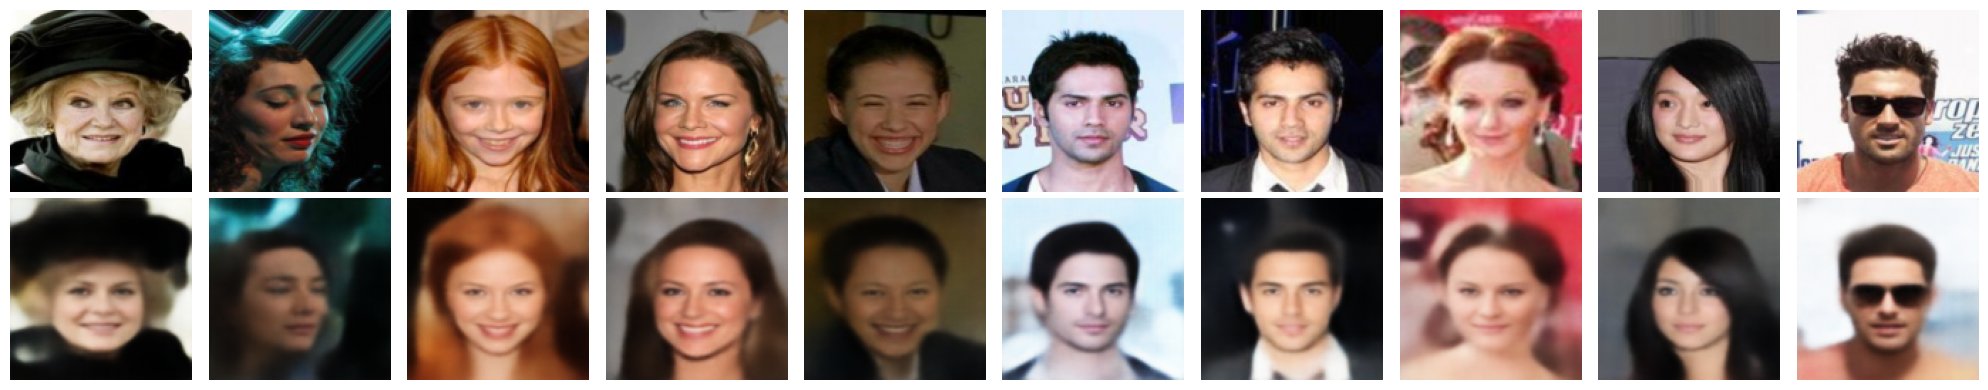

In [11]:
X, y = next(iter(test_dataloader))
X = X.to(device)
y=y.to(device)
pred, _, _ = model(X,y)
def plot_images(originals, predictions, num_images=10):
    fig, axes = plt.subplots(2, num_images, figsize=(2 * num_images, 4))
    for i in range(num_images):
        axes[0, i].imshow(originals[i].permute(1, 2, 0).cpu().squeeze())
        axes[0, i].axis("off")
        axes[1, i].imshow(predictions[i].permute(1, 2, 0).detach().cpu().squeeze())
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Reconstruit")
    plt.tight_layout()
    plt.show()

plot_images(X, pred, num_images=10)

## Génération aléatoire avec lunettes

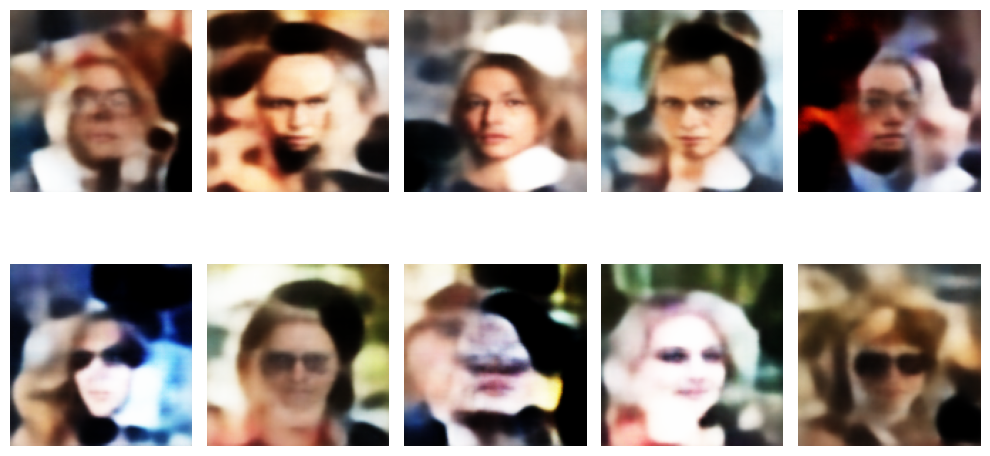

In [14]:
import matplotlib.pyplot as plt
import torch
import numpy as np

latent_dim =512
fig, axes = plt.subplots(2, 5, figsize=(10, 6))
axes = axes.flatten()

for i in range(10):
    # Génère mu et logvar aléatoirement
    mean = torch.randn(1, latent_dim).to(device)
    log_var = torch.randn(1, latent_dim).to(device)
    feature=[0]*40
    feature[15]=1
    feature[9]=1
    feature = torch.tensor(feature, dtype=torch.float32).unsqueeze(0).to(device)
    # Reparameterize
    with torch.no_grad():
        z = model.reparameterize(mean, log_var)
        y = model.decode(z,feature)

    # Format image
    image = y.cpu().squeeze().numpy()
    image = np.transpose(image, (1, 2, 0))  # (H, W, C)

    axes[i].imshow(image, cmap="gray")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from PIL import Image

import torchvision.transforms as T

for i in (2, 15):
  image =  Image.open("../1702842431689.jpeg")


  transform = T.Compose([
      T.Resize((128, 128)),
      T.ToTensor(),
  ])

  img_tensor = transform(image).unsqueeze(0).to(device)

  feature = [0] * 40
  feature[i] = 1
  feature_tensor = torch.tensor(feature, dtype=torch.float32).unsqueeze(0).to(device)


  with torch.no_grad():
      pred, _, _ = model(img_tensor, feature_tensor)

  pred = pred.reshape(1, 3, 128,128)

  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  axes[0].imshow(img_tensor.squeeze().permute(1, 2, 0).cpu().squeeze())
  axes[0].axis("off")

  axes[1].imshow(pred.squeeze().permute(1, 2, 0).detach().cpu().squeeze())
  axes[1].axis("off")
  axes[1].set_title(features[np.array(feature)==1])

  plt.tight_layout()
  plt.show()

In [ ]:
image